# Data Classification Using KNN — Iris Dataset
**DecodeLabs AI Industrial Training | Batch 2026 | Project 2**

---

## Project Overview

This notebook implements a complete supervised machine learning pipeline using the **K-Nearest Neighbors (KNN)** algorithm on the classic **Iris dataset**.

We follow the **IPO (Input → Process → Output)** framework:

| Phase | Steps |
|-------|-------|
| **INPUT** | Load dataset → Explore → Feature Scaling |
| **PROCESS** | Train-Test Split → K-Tuning → Train KNN |
| **OUTPUT** | Confusion Matrix → F1 Score → Evaluation |

## Step 1 — Import Dependencies

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, classification_report, accuracy_score

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Phase 1 — INPUT

### Step 2 — Load & Explore the Dataset

The **Iris dataset** is a benchmark dataset in machine learning:
- **150 samples** (rows), **4 features** (columns), **3 classes** (labels)
- Classes: *Setosa*, *Versicolor*, *Virginica* — 50 samples each (perfectly balanced)
- Features: Sepal Length, Sepal Width, Petal Length, Petal Width (all in cm)

Balanced classes mean no class is over-represented, so accuracy is a fair metric here.

In [14]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print(f'Dataset shape: {df.shape}')
print(f'Feature names: {iris.feature_names}')
print(f'Class names: {iris.target_names.tolist()}')
print()
df.head(10)

Dataset shape: (150, 6)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa', 'versicolor', 'virginica']



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
5,5.4,3.9,1.7,0.4,0,Setosa
6,4.6,3.4,1.4,0.3,0,Setosa
7,5.0,3.4,1.5,0.2,0,Setosa
8,4.4,2.9,1.4,0.2,0,Setosa
9,4.9,3.1,1.5,0.1,0,Setosa


In [15]:
print('--- Statistical Summary ---')
display(df.drop(columns=['target', 'species']).describe().round(2))

print('\n--- Class Distribution ---')
print(df['species'].value_counts())

--- Statistical Summary ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



--- Class Distribution ---
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


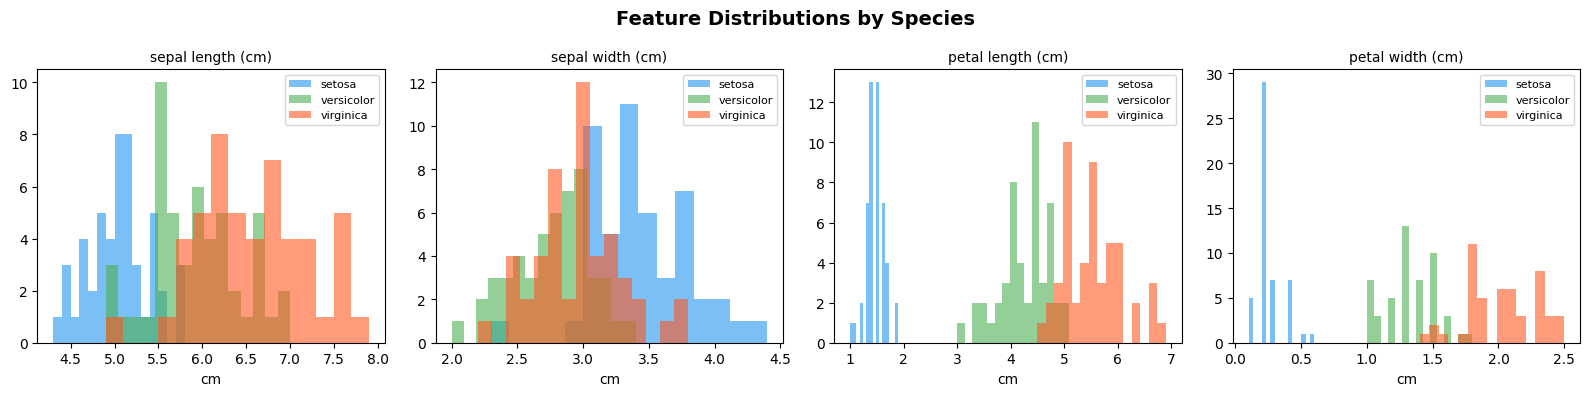

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF5722']
for i, feature in enumerate(iris.feature_names):
    for j, species in enumerate(iris.target_names):
        axes[i].hist(df[df['species'] == species.capitalize()][feature],
                     bins=15, alpha=0.6, color=colors[j], label=species)
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('cm')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Step 3 — Feature Scaling (StandardScaler)

KNN classifies a new point by measuring its **Euclidean distance** to the k nearest training points. This means feature scale directly affects the result.

**Problem:** Sepal Length ranges ~4–8 cm while Petal Width ranges ~0.1–2.5 cm. Without scaling, Sepal Length would dominate every distance calculation simply because its numbers are larger — not because it's more important.

**Solution:** `StandardScaler` transforms each feature to have **mean = 0** and **variance = 1**:

$$z = \frac{x - \mu}{\sigma}$$

**Important — No Data Leakage:** We split the data first, then fit the scaler **only on the training set**. If we fitted on the full dataset, the scaler would "see" test data statistics during training — the model would be tuned to information it should never have had access to. The scaler is applied to the test set using the training set's mean and std.

In [17]:
X = iris.data
y = iris.target

print('Raw feature ranges (motivates scaling):')
for i, name in enumerate(iris.feature_names):
    print(f'  {name:<25}  min={X[:, i].min():.1f}  max={X[:, i].max():.1f}  mean={X[:, i].mean():.2f}')

print()
print('Without scaling, Sepal Length (range ~4) would dominate Petal Width (range ~2.4)')
print('in every distance calculation — purely due to magnitude, not importance.')
print('Scaling will be applied AFTER the train-test split to avoid data leakage.')

Raw feature ranges (motivates scaling):
  sepal length (cm)          min=4.3  max=7.9  mean=5.84
  sepal width (cm)           min=2.0  max=4.4  mean=3.06
  petal length (cm)          min=1.0  max=6.9  mean=3.76
  petal width (cm)           min=0.1  max=2.5  mean=1.20

Without scaling, Sepal Length (range ~4) would dominate Petal Width (range ~2.4)
in every distance calculation — purely due to magnitude, not importance.
Scaling will be applied AFTER the train-test split to avoid data leakage.


---
## Phase 2 — PROCESS

### Step 4 — Train-Test Split (80/20) + Feature Scaling

We split the data first, then scale — in that order.

- **80% training set** (120 samples) — the model learns from this
- **20% test set** (30 samples) — the model is evaluated on this
- `random_state=42` — fixes the random seed for reproducibility
- `shuffle=True` (default) — randomizes order before splitting, removing any ordering bias in the original dataset (Iris is sorted by class)

Scaling order:
1. `scaler.fit_transform(X_train)` — compute mean/std from training data only, then scale
2. `scaler.transform(X_test)` — apply the training mean/std to the test set (no re-fitting)

In [18]:
# Split on raw (unscaled) data first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Fit scaler ONLY on training data, then apply to both sets
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training set size : {X_train.shape[0]} samples (80%)')
print(f'Test set size     : {X_test.shape[0]} samples (20%)')

train_classes, train_counts = np.unique(y_train, return_counts=True)
test_classes, test_counts = np.unique(y_test, return_counts=True)
print(f'\nTrain class distribution: {dict(zip(iris.target_names, train_counts))}')
print(f'Test  class distribution: {dict(zip(iris.target_names, test_counts))}')

print(f'\nTraining feature means (should be ~0): {X_train.mean(axis=0).round(4)}')
print(f'Training feature stds  (should be ~1): {X_train.std(axis=0).round(4)}')

Training set size : 120 samples (80%)
Test set size     : 30 samples (20%)

Train class distribution: {np.str_('setosa'): np.int64(40), np.str_('versicolor'): np.int64(41), np.str_('virginica'): np.int64(39)}
Test  class distribution: {np.str_('setosa'): np.int64(10), np.str_('versicolor'): np.int64(9), np.str_('virginica'): np.int64(11)}

Training feature means (should be ~0): [ 0. -0. -0. -0.]
Training feature stds  (should be ~1): [1. 1. 1. 1.]


### Step 5 — K-Tuning: Finding the Optimal k

The **k** parameter controls how many neighbors vote on each prediction. Choosing the right k is critical:

- **k too small (e.g. k=1):** The model memorizes the training data → **overfitting**. It performs perfectly on training data but poorly on unseen data.
- **k too large (e.g. k=100):** The model considers too many neighbours, blurring decision boundaries → **underfitting**.
- **Sweet spot:** The "elbow" in the error rate curve — where adding more neighbours stops improving performance.

We test k = 1 to 20 and plot the test error rate to confirm k=5 is a good choice.

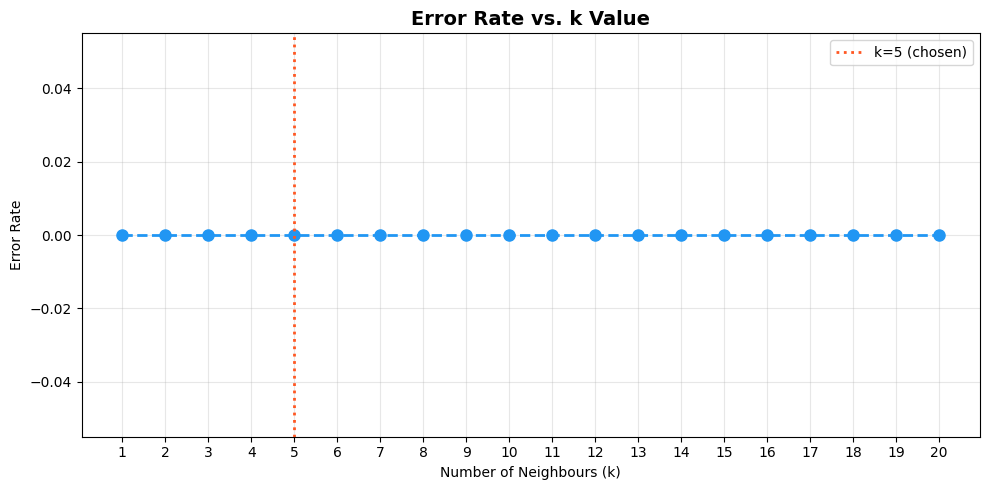

Lowest error rate at k=1 (0.0% error)
Error rate at k=5: 0.0%


In [19]:
error_rates = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error_rates.append(np.mean(preds != y_test))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), error_rates, marker='o', linestyle='--',
         color='#2196F3', linewidth=2, markersize=8)
plt.axvline(x=5, color='#FF5722', linestyle=':', linewidth=2, label='k=5 (chosen)')
plt.title('Error Rate vs. k Value', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbours (k)')
plt.ylabel('Error Rate')
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = error_rates.index(min(error_rates)) + 1
print(f'Lowest error rate at k={best_k} ({min(error_rates)*100:.1f}% error)')
print(f'Error rate at k=5: {error_rates[4]*100:.1f}%')

### Step 6 — Train the KNN Model (k=5)

The KNN algorithm does not build an explicit model — it memorizes the entire training set and uses the **Proximity Principle**: *similar things exist in close proximity*.

At prediction time, for each test point it:
1. Calculates the Euclidean distance to all 120 training points
2. Picks the 5 nearest neighbours
3. Takes a **majority vote** among their labels → that is the predicted class

In [20]:
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)
print('Model trained (training patterns memorized).')

y_pred = model.predict(X_test)
print(f'Predictions made for {len(y_pred)} test samples.')

print(f'\nActual labels    : {y_test}')
print(f'Predicted labels : {y_pred}')

mismatches = np.where(y_test != y_pred)[0]
print(f'\nMisclassified samples: {len(mismatches)} out of {len(y_test)}')

Model trained (training patterns memorized).
Predictions made for 30 test samples.

Actual labels    : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Predicted labels : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Misclassified samples: 0 out of 30


---
## Phase 3 — OUTPUT

### Step 7 — Confusion Matrix

The confusion matrix shows exactly where the model is correct and where it makes mistakes:

- **Diagonal cells** (top-left to bottom-right) = correct predictions
- **Off-diagonal cells** = misclassifications (which class was confused with which)

This is more informative than a single accuracy number — it reveals *how* the model fails.

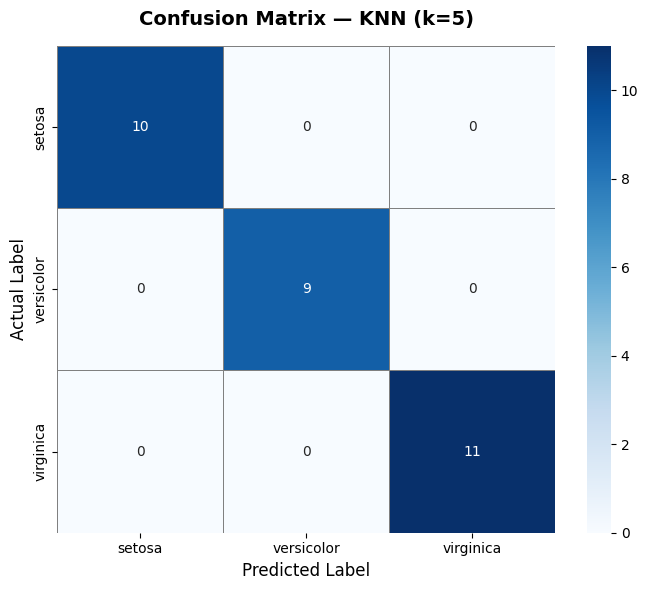

Confusion Matrix (raw):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [21]:
cm = confusion_matrix(y_test, y_pred)
class_names = iris.target_names

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Confusion Matrix — KNN (k=5)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print('Confusion Matrix (raw):')
print(cm)

### Step 8 — F1 Score & Classification Report

Accuracy alone can be misleading. We use additional metrics:

| Metric | Formula | Meaning |
|--------|---------|----------|
| **Precision** | TP / (TP + FP) | Of all predicted positives, how many were truly positive? |
| **Recall** | TP / (TP + FN) | Of all actual positives, how many did we catch? |
| **F1 Score** | 2 × (P × R) / (P + R) | Harmonic mean — balances Precision and Recall |

We use `average='weighted'` because it accounts for each class's support (sample count), which is appropriate even for balanced datasets.

In [22]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy : {accuracy * 100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print()
print('--- Full Classification Report ---')
print(classification_report(y_test, y_pred, target_names=class_names))

Accuracy : 100.00%
F1 Score : 1.0000

--- Full Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Step 9 — Cross-Validation: Is the Score Realistic?

A single 80/20 split gives **one** result — it depends heavily on which 30 samples happened to end up in the test set. With only 30 test samples, a lucky split can produce 100%, while an unlucky one might give 87%.

**5-Fold Cross-Validation** gives a much more honest picture:
- The dataset is divided into 5 equal folds
- The model is trained and tested 5 times, each time using a different fold as the test set
- The 5 scores are averaged → stable, representative estimate of true performance

This is why a single split score should always be validated with cross-validation.

In [23]:
# Cross-validate on the full (unscaled) dataset using a pipeline
# We reuse the raw X so each fold is scaled independently (no leakage)
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

cv_scores = cross_val_score(pipeline, iris.data, iris.target, cv=5, scoring='accuracy')

print('5-Fold Cross-Validation Accuracy per fold:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score * 100:.2f}%')

print(f'\nMean accuracy : {cv_scores.mean() * 100:.2f}%')
print(f'Std deviation : ±{cv_scores.std() * 100:.2f}%')
print()
print(f'Single split result (random_state=42): {accuracy * 100:.2f}%')
print(f'Cross-validation mean               : {cv_scores.mean() * 100:.2f}%')
print()
print('The cross-validation mean is the more reliable performance estimate.')

5-Fold Cross-Validation Accuracy per fold:
  Fold 1: 96.67%
  Fold 2: 96.67%
  Fold 3: 93.33%
  Fold 4: 93.33%
  Fold 5: 100.00%

Mean accuracy : 96.00%
Std deviation : ±2.49%

Single split result (random_state=42): 100.00%
Cross-validation mean               : 96.00%

The cross-validation mean is the more reliable performance estimate.


### Step 10 — Visualising Correct vs Incorrect Predictions

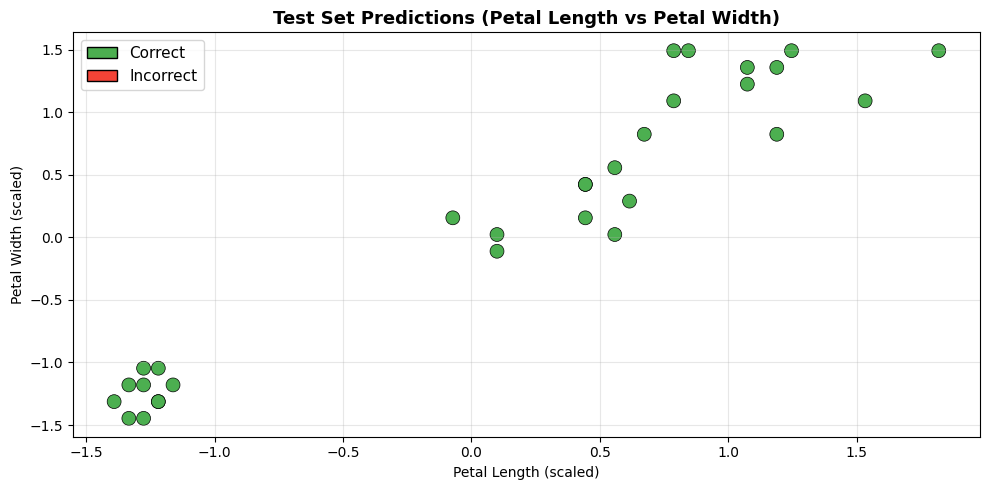

In [24]:
correct_mask = y_test == y_pred
colors_pred = ['#4CAF50' if c else '#F44336' for c in correct_mask]

plt.figure(figsize=(10, 5))
plt.scatter(
    X_test[:, 2],
    X_test[:, 3],
    c=colors_pred,
    s=100,
    edgecolors='black',
    linewidth=0.5
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', edgecolor='black', label='Correct'),
    Patch(facecolor='#F44336', edgecolor='black', label='Incorrect')
]
plt.legend(handles=legend_elements, fontsize=11)
plt.title('Test Set Predictions (Petal Length vs Petal Width)', fontsize=13, fontweight='bold')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

| Item | Value |
|------|-------|
| Dataset | Iris (150 samples, 4 features, 3 classes) |
| Algorithm | K-Nearest Neighbors |
| k value | 5 |
| Feature Scaling | StandardScaler — fitted on train only |
| Train / Test split | 80% / 20% (random_state=42) |
| Single-split accuracy | see Step 8 output |
| Cross-validation accuracy | see Step 9 output (more reliable) |

---

## What I Learned

1. **Feature Scaling is mandatory for KNN** — because KNN relies on Euclidean distance, features on different scales would otherwise produce biased distances. StandardScaler normalises them to a common range.

2. **Shuffling before splitting matters** — the Iris dataset is ordered by class. Without shuffling, the test set would contain only the last class, giving a completely misleading result.

3. **Scaling must happen AFTER splitting to avoid data leakage** — fitting the scaler on the full dataset before splitting lets test-set statistics "leak" into the preprocessing. The correct order is: split first, then fit the scaler only on training data, then transform both sets.

4. **k is a tunable hyperparameter** — too small leads to overfitting, too large leads to underfitting. The error-rate curve reveals the optimal "elbow" point.

5. **A single split score can be misleading** — with only 30 test samples, results vary significantly between splits (86%–100%). Cross-validation over 5 folds gives a stable, trustworthy estimate of true model performance.

6. **The Confusion Matrix tells a richer story than accuracy** — it shows *which classes* the model confuses, not just how many mistakes it makes. Versicolor and Virginica are harder to separate than Setosa because their features overlap more.

7. **F1 Score balances Precision and Recall** — it is the preferred metric when both false positives and false negatives carry a cost (e.g. medical diagnosis, spam filters).